In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv('/Users/razikarahman/projects/data-analysis/data/processed/zara_cleaned.csv', sep=",")

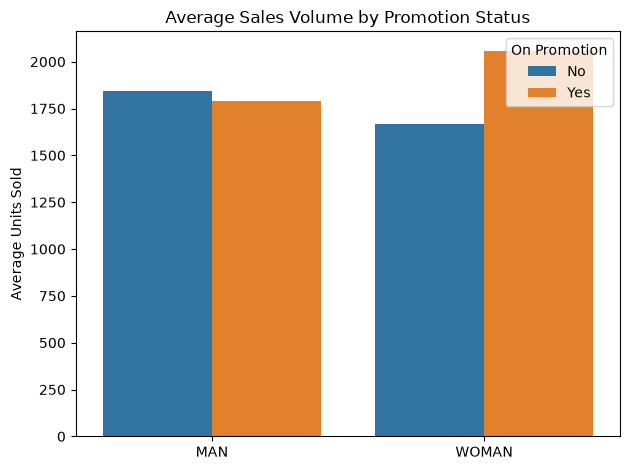

In [15]:
# Promotion vs Sales Volume

promo_summary = df.groupby(["section", "promotion"]).agg(
    avg_sales=("sales_volume", "mean")
).reset_index()

ax = sns.barplot(data=promo_summary, x="section", y="avg_sales", hue="promotion")
ax.set_title("Average Sales Volume by Promotion Status")
ax.set_ylabel("Average Units Sold")
ax.set_xlabel("")
ax.legend(title="On Promotion")

plt.tight_layout()
plt.show()

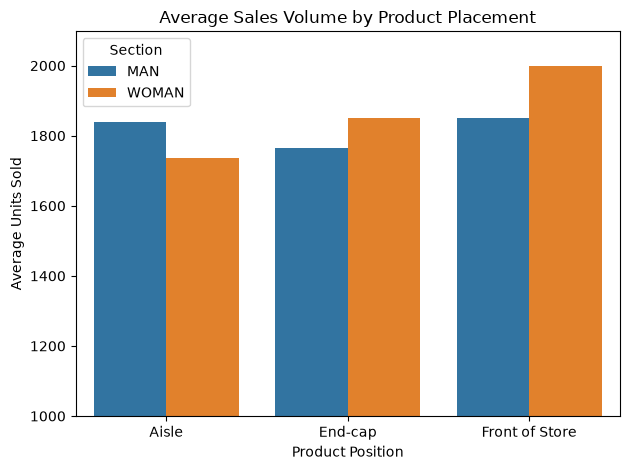

In [16]:
# Product Placement vs Sales Volume
position_summary = df.groupby(["product_position", "section"]).agg(
    avg_sales=("sales_volume", "mean")
).reset_index()

ax = sns.barplot(data=position_summary, x="product_position", y="avg_sales", hue="section")
ax.set_title("Average Sales Volume by Product Placement")
ax.set_xlabel("Product Position")
ax.set_ylabel("Average Units Sold")
ax.set_ylim(1000)
ax.legend(title="Section")
plt.tight_layout()
plt.show()

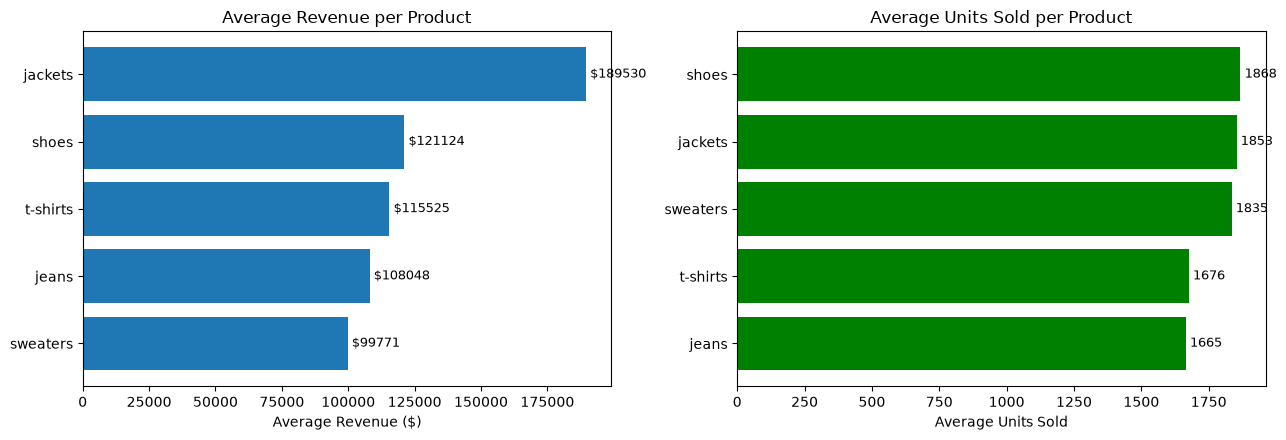

In [17]:
# Categories vs. Sales & Revenue

category_summary = df.groupby("category").agg(
    product_count=("product_id", "count"),
    avg_sales=("sales_volume", "mean"),
    avg_revenue=("product_revenue", "mean")
).reset_index().sort_values("avg_revenue", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

b1 = axes[0].barh(category_summary["category"], category_summary["avg_revenue"])
axes[0].set_title("Average Revenue per Product")
axes[0].set_xlabel("Average Revenue ($)")
axes[0].invert_yaxis()
axes[0].bar_label(b1, fmt="$%.0f", padding=3, fontsize=9)

cat_by_sales = category_summary.sort_values("avg_sales", ascending=False)
b2 = axes[1].barh(cat_by_sales["category"], cat_by_sales["avg_sales"], color="green")
axes[1].set_title("Average Units Sold per Product")
axes[1].set_xlabel("Average Units Sold")
axes[1].invert_yaxis()
axes[1].bar_label(b2, fmt="%.0f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()

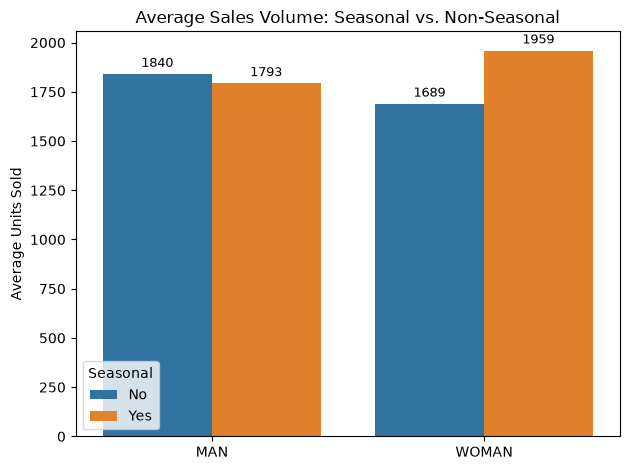

In [18]:
# Seasonal Products vs. Sales

seasonal_summary = df.groupby(["section", "seasonal"]).agg(
    avg_sales=("sales_volume", "mean")
).reset_index()

ax = sns.barplot(data=seasonal_summary, x="section", y="avg_sales", hue="seasonal",)
ax.set_title("Average Sales Volume: Seasonal vs. Non-Seasonal")
ax.set_xlabel("")
ax.set_ylabel("Average Units Sold")
ax.legend(title="Seasonal")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()